regiones y fronteras

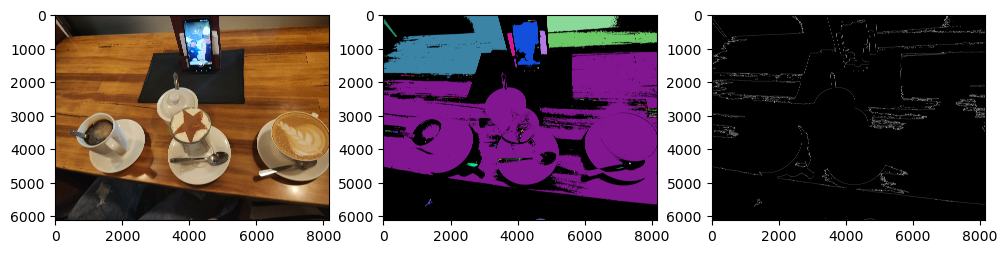

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("imagenes/colores.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#combino tecnicas 
blur = cv2.GaussianBlur(gray, (7,7), 0)
_,binary = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#ENCONTRAMOS REGIONES
num_l,label = cv2.connectedComponents(binary)
#idetificamos por colores
color = np.random.randint(0,255,size = (num_l,3),dtype=np.uint8)
#fondo negro
color[0] = [0,0,0]
colorear = color[label]

#encotrar fronteras
contornos,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contono_fin = cv2.drawContours(np.zeros_like(gray),contornos,-1,255,2)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(132)
plt.imshow(colorear)
plt.subplot(133)
plt.imshow(contono_fin,cmap='gray')
plt.show()

CONTEO

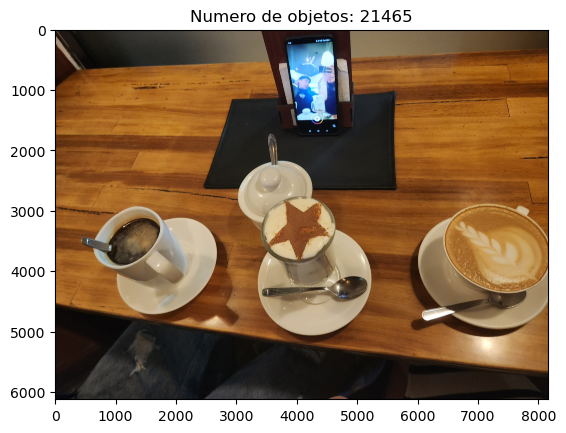

In [14]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt 
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # constante correcta
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2)  # 2 = conectividad 4, 1 = conectividad 8
    num_obj = np.max(e_img)
    return num_obj

imagen = cv2.imread("imagenes/colores.jpg")
conteo = contar_elementos(imagen)

plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f"Numero de objetos: {conteo}")
plt.show()


ACT. REGIONES FRONTERAS Y CONTEO

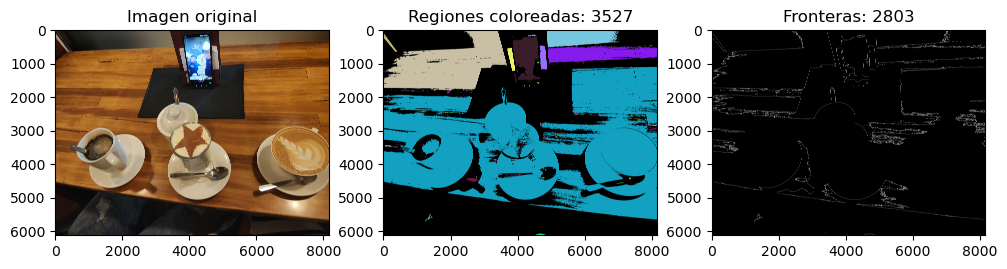

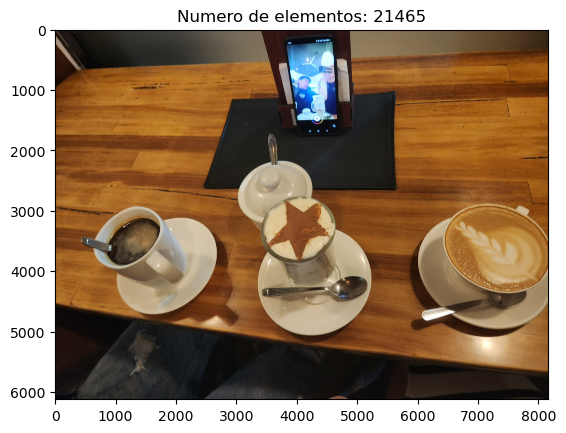

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# Regiones y fronteras
img = cv2.imread("imagenes/colores.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#combino tecnicas 
blur = cv2.GaussianBlur(gray, (7,7), 0)
_,binary = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#ENCONTRAMOS REGIONES
num_l,label = cv2.connectedComponents(binary)
#identificamos por colores
color = np.random.randint(0,255,size = (num_l,3),dtype=np.uint8)
#fondo negro
color[0] = [0,0,0]
colorear = color[label]

#encontrar fronteras
contornos,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contono_fin = cv2.drawContours(np.zeros_like(gray),contornos,-1,255,2)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.subplot(132)
plt.imshow(colorear)
plt.title(f"Regiones coloreadas: {num_l-1}")
plt.subplot(133)
plt.imshow(contono_fin,cmap='gray')
plt.title(f"Fronteras: {len(contornos)}")
plt.show()

# Contar elementos
def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2) #2=conectividad es de 4  1=conectividad de 8
    num_obj = np.max(e_img)
    
    return num_obj

imagen = cv2.imread("imagenes/colores.jpg")
conteo = contar_elementos(imagen)
plt.figure()
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f"Numero de elementos: {conteo}")
plt.show()